# LSST SN Ia Simulation Pipeline

Forward-model SN Ia light curves with the lsstcam Science Validation cadence using `lightcurvelynx`.

**Survey**: lsstcam Science Validation visits (`lsstcam_20250930.db`)  
**Model**: SALT3 via `SncosmoWrapperModel`  
**Filters**: u, g, r, i, z, y  
**Redshift**: volumetric rate (Frohmaier et al. 2019), z = 0.01–1.2  
**Parameters**: Gaussian priors for x1 and c (no pzflow, no host galaxy)

## 1. Imports

## 0. Environment Setup

Set `LIGHTCURVELYNX_DATA_DIR` **before** importing lightcurvelynx — the download path is resolved at import time.  
Downloaded files (OpSim DB, passbands) will be stored in `./data/` inside this project directory.

In [1]:
# auto reload
%load_ext autoreload
%autoreload 2

In [2]:
import os
from pathlib import Path

# Store downloaded data inside this project so it travels with the repo checkout.
# Must be set before any lightcurvelynx imports (path is resolved at import time).
_data_dir = Path().resolve() / "data"
_data_dir.mkdir(exist_ok=True)
os.environ["LIGHTCURVELYNX_DATA_DIR"] = str(_data_dir)
print(f"LIGHTCURVELYNX_DATA_DIR = {_data_dir}")

LIGHTCURVELYNX_DATA_DIR = /Users/mi/Work/lightcurvelynx_rubin_dp2/data


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from nested_pandas import read_parquet
from joblib import Parallel, delayed
import sncosmo

from lightcurvelynx.obstable.lsst_obstable import LSSTObsTable
from lightcurvelynx.utils.io_utils import read_sqlite_table
from lightcurvelynx.astro_utils.passbands import PassbandGroup
from lightcurvelynx.astro_utils.snia_utils import (
    DistModFromRedshift,
    X0FromDistMod,
    num_snia_per_redshift_bin,
    snia_volumetric_rates,
)
from lightcurvelynx.math_nodes.np_random import NumpyRandomFunc
from lightcurvelynx.math_nodes.scipy_random import SamplePDF
from lightcurvelynx.math_nodes.ra_dec_sampler import ObsTableUniformRADECSampler,ApproximateMOCSampler
from lightcurvelynx.models.sncosmo_models import SncosmoWrapperModel
from lightcurvelynx.simulate import simulate_lightcurves
from lightcurvelynx.utils.extrapolate import LinearDecayOnMag,ZeroPadding
from lightcurvelynx.astro_utils.dustmap import DustmapWrapper,SFDMap
from lightcurvelynx.effects.extinction import ExtinctionEffect

## 2. Simulation Configuration

In [4]:
SEED = 1024
RNG  = np.random.default_rng(SEED)

SIM_PARAMS = {
    # Cosmology
    "H0": 73.0,
    "Omega_m": 0.3,
    # Redshift range
    "zmin": 0.01,
    "zmax": 1.2,
    "znbins": 100,
    # Tripp relation coefficients
    "alpha": 0.14,
    "beta": 3.1,
    # SALT3 Gaussian priors (no pzflow, no host galaxy)
    "x1_mean": 0.0,  "x1_sigma": 1.0,
    "c_mean":  0.0,  "c_sigma":  0.1,
    "m_abs_mean": -19.3, "m_abs_sigma": 0.12,
    # Survey
    "filters": ["u", "g", "r", "i", "z", "y"],
    "sky_coverage": 18_000.0,  # LSST WFD footprint in deg²
}

## 3. Load LSST Visit Table

In [5]:
_sv_table = read_sqlite_table(
    "data/visittable/lsstcam_20250930.db",
    sql_query="SELECT * FROM observations",
)
_sv_table_dd = _sv_table[_sv_table['observation_reason'].str.contains('ddf')]

obstable = LSSTObsTable.from_sv_visits_table(_sv_table_dd)
print(f"Visit table loaded: {len(obstable):,} observations")
print(f"MJD range: {obstable['time'].min():.1f} – {obstable['time'].max():.1f}")
print(f"Filters:    {sorted(obstable['filter'].unique())}")

Visit table loaded: 834 observations
MJD range: 60856.3 – 60940.1
Filters:    ['g', 'i', 'r', 'u', 'y', 'z']


In [6]:
sky_coverage = obstable.estimate_coverage()    
# sky_coverage = 75
SIM_PARAMS["sky_coverage"] = sky_coverage
print(f"Estimated sky coverage: {sky_coverage:.0f} deg²")

Estimated sky coverage: 67 deg²


## 4. Calculate Number of SNe to Simulate

Integrate the volumetric SN Ia rate over the survey volume and duration:
$$N = \int_{z_{\rm min}}^{z_{\rm max}} r_v(z)\,\frac{dV}{dz}\,\frac{dz}{1+z} \times \Omega \times T_{\rm survey}$$

In [7]:
t_min = float(obstable["time"].min())
t_max = float(obstable["time"].max())

survey_length = (t_max - t_min) / 365.25
print(f"Survey length = {survey_length:.2f} years")

solid_angle = SIM_PARAMS["sky_coverage"] * (np.pi / 180.0) ** 2
print(f"Solid angle   = {solid_angle:.4f} sr  ({SIM_PARAMS['sky_coverage']:,.0f} deg²)")

nsntotal, _ = num_snia_per_redshift_bin(
    SIM_PARAMS["zmin"],
    SIM_PARAMS["zmax"],
    znbins=1,
    solid_angle=solid_angle,
    vol_rate_function=snia_volumetric_rates,
    H0=SIM_PARAMS["H0"],
    Omega_m=SIM_PARAMS["Omega_m"],
)
nsn = int(nsntotal[0] * survey_length)
# nsn = 100
print(f"Expected SNe Ia = {nsn:,}")

Survey length = 0.23 years
Solid angle   = 0.0203 sr  (67 deg²)
Expected SNe Ia = 2,861


## 5. Load LSST Passbands

In [8]:
passbands = PassbandGroup.from_preset("LSST", filters=SIM_PARAMS["filters"])
print(passbands)

PassbandGroup containing 6 passbands: LSST_u, LSST_g, LSST_r, LSST_i, LSST_z, LSST_y


## 6. Redshift Distribution (Volumetric Rate)

Use the Frohmaier et al. (2019) volumetric rate $r_v(z) = r_0\,(1+z)^\alpha$ to compute the
expected number of SNe Ia per redshift bin, then build an interpolated PDF for sampling.

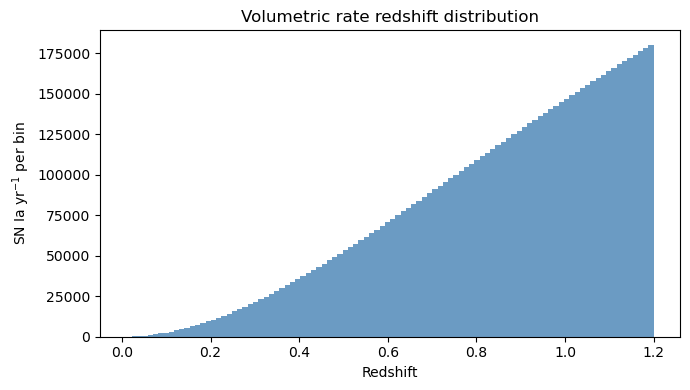

In [9]:
nsn_per_bin, z_mean = num_snia_per_redshift_bin(
    SIM_PARAMS["zmin"],
    SIM_PARAMS["zmax"],
    SIM_PARAMS["znbins"],
    H0=SIM_PARAMS["H0"],
    Omega_m=SIM_PARAMS["Omega_m"],
)
zpdf = interp1d(z_mean, nsn_per_bin, bounds_error=False, fill_value=0)

fig, ax = plt.subplots(figsize=(7, 4))
dz = (SIM_PARAMS["zmax"] - SIM_PARAMS["zmin"]) / SIM_PARAMS["znbins"]
ax.bar(z_mean, nsn_per_bin, width=dz, color="steelblue", alpha=0.8)
ax.set(xlabel="Redshift", ylabel="SN Ia yr$^{-1}$ per bin",
       title="Volumetric rate redshift distribution")
plt.tight_layout()
plt.show()

## 7. Build SN Ia Source Model

Parameter graph:
- **RA, Dec** — uniformly sampled from the observed LSST footprint (`ObsTableUniformRADECSampler`)
- **redshift** — drawn from the volumetric rate PDF (`SamplePDF`)
- **x1** — Gaussian($\mu=0$, $\sigma=1$)
- **c** — Gaussian($\mu=0$, $\sigma=0.1$)
- **M_abs** — Gaussian($\mu=-19.3$, $\sigma=0.12$)
- **distmod** — computed from redshift via `DistModFromRedshift`
- **x0** — computed via the Tripp relation through `X0FromDistMod`

In [10]:
# RA/Dec: uniform over the obstable footprint (rejection sampling)
# radec = ObsTableUniformRADECSampler(obstable, node_label="radec")
moc = obstable.build_moc(max_depth=12)
radec = ApproximateMOCSampler(moc, node_label="radec")

# Redshift from volumetric rate PDF
z_func = SamplePDF(zpdf, node_label="redshift")

# Gaussian SALT3 parameter priors
x1_func    = NumpyRandomFunc("normal", loc=SIM_PARAMS["x1_mean"],    scale=SIM_PARAMS["x1_sigma"])
c_func     = NumpyRandomFunc("normal", loc=SIM_PARAMS["c_mean"],     scale=SIM_PARAMS["c_sigma"])
m_abs_func = NumpyRandomFunc("normal", loc=SIM_PARAMS["m_abs_mean"], scale=SIM_PARAMS["m_abs_sigma"])

# x0 via Tripp relation
distmod_func = DistModFromRedshift(
    z_func, H0=SIM_PARAMS["H0"], Omega_m=SIM_PARAMS["Omega_m"]
)
x0_func = X0FromDistMod(
    distmod=distmod_func,
    x1=x1_func,
    c=c_func,
    alpha=SIM_PARAMS["alpha"],
    beta=SIM_PARAMS["beta"],
    m_abs=m_abs_func,
    node_label="x0_func",
)

# Extrapolation settings
time_extrap_before = ZeroPadding()
time_extrap_after = LinearDecayOnMag(decay_rate=0.02, mag_thres=30.)
wave_extrap_before = ZeroPadding()
wave_extrap_after = ZeroPadding()

# Assemble the SALT3 source (no host galaxy)
source = SncosmoWrapperModel(
    "salt3",
    t0=NumpyRandomFunc("uniform", low=t_min, high=t_max),
    x0=x0_func,
    x1=x1_func,
    c=c_func,
    ra=radec.ra,
    dec=radec.dec,
    redshift=z_func,
    node_label="source",
    time_extrapolation=(time_extrap_before,time_extrap_after),
    wave_extrapolation=(wave_extrap_before,wave_extrap_after),  
)

mwextinction = SFDMap(
    ra=source.ra,
    dec=source.dec,
    node_label="mwext",
)
# Create an extinction effect using the EBVs from that dust map.
ext_effect = ExtinctionEffect(extinction_model="F99", ebv=mwextinction, 
                              r_v=3.1,frame='observer',backend="dust_extinction")
source.add_effect(ext_effect)

print("Source model built successfully.")

Source model built successfully.


## 8. Run Simulation

In [11]:
obstable.columns

Index(['observationId', 'exposure_name', 'controller', 'day_obs', 'seq_num',
       'physical_filter', 'filter', 'ra', 'dec', 'rotation',
       ...
       'slew_model', 'slew_model_ideal', 'model_gap', 'slewDistance',
       'overhead', 'fault', 'jd', 'nexp', 'night', 'zp'],
      dtype='object', length=218)

In [12]:
param_cols = [
    "source.t0",
    "source.x0",
    "source.x1",
    "source.c",
    "source.redshift",
    "source.ra",
    "source.dec",
    "x0_func.distmod",
]
obstable_save_cols = ["zp"]

lightcurves = simulate_lightcurves(
    model=source,
    num_samples=nsn,
    obstable=obstable,
    passbands=passbands,
    param_cols=param_cols,
    obstable_save_cols=obstable_save_cols,
    rng=RNG,
    num_jobs=6,
    batch_size=3000,
)
print(f"Simulated {len(lightcurves):,} SNe Ia")
lightcurves.head()

Simulating: 100%|██████████| 477/477 [00:02<00:00, 224.95obj/s]


Simulated 2,861 SNe Ia


id         ra        dec  nobs            t0         z  \
0   0  11.867593 -45.209292    23  60937.827954  0.786800   
1   1   8.870330 -42.934192   491  60920.350648  1.176615   
2   2  52.913941 -26.159575     5  60899.602097  0.667333   
3   3  52.818039 -28.758889   160  60875.427854  0.449353   
4   4  56.317808 -49.306340    35  60867.911150  0.672795   

                                              params     source_t0  source_x0  \
0  {'radec.ra': 11.86759251525588, 'radec.dec': -...  60937.827954   0.000006   
1  {'radec.ra': 8.870330007108596, 'radec.dec': -...  60920.350648   0.000002   
2  {'radec.ra': 52.91394118219614, 'radec.dec': -...  60899.602097   0.000006   
3  {'radec.ra': 52.81803930178285, 'radec.dec': -...  60875.427854   0.000034   
4  {'radec.ra': 56.317807783511306, 'radec.dec': ...  60867.911150   0.000006   

   source_x1  source_c  source_redshift  source_ra  source_dec  \
0  -0.252553 -0.110452         0.786800  11.867593  -45.209292   
1  -0.058708 -0.077809         1.176615   8.870330  -42.934192   
2  -0.067256  0.052440         0.667333  52.913941  -26.159575   
3   0.659269 -0.185067         0.449353  52.818039  -28.758889   
4  -0.680440 -0.036100         0.672795  56.317808  -49.306340   

   x0_func_distmod                                         lightcurve  
0        43.367029  [{mjd: 60916.163545, filter: 'i', flux: 692.22...  
1        44.446028  [{mjd: 60856.266898, filter: 'u', flux: -521.5...  
2        42.928968  [{mjd: 60925.190512, filter: 'z', flux: 1403.8...  
3        41.892858  [{mjd: 60868.330099, filter: 'g', flux: 7538.9...  
4        42.950576  [{mjd: 60870.368549, filter: 'g', flux: 667.75...

## 9. Save Results

In [13]:
# # save results
# output_path = "outputs/lsst_snia_results.parquet"
# output_path = Path(output_path)
# output_path.parent.mkdir(exist_ok=True)
# lightcurves.to_parquet(output_path)
# print(f"Saved to {output_path}")

In [14]:
# lightcurves = read_parquet("outputs/lsst_snia_results.parquet")

## 10. Apply Selections

In [15]:
# calculate detection flag
lightcurves = lightcurves.dropna(subset=['lightcurve'])

print("Before applying detection: nsn=", len(lightcurves))
lightcurves['lightcurve.snr'] = lightcurves['lightcurve.flux']/lightcurves['lightcurve.fluxerr']
detection_snr_thres = 5.
lightcurves['lightcurve.detection_flag'] = lightcurves['lightcurve.snr'] > detection_snr_thres

# drop saturation
lightcurves_after_drop_sat = lightcurves.query("lightcurve.is_saturated==False").dropna(subset=['lightcurve'])
print("After droppoing saturation: nsn=", len(lightcurves_after_drop_sat))

lightcurves_after_detection = lightcurves_after_drop_sat.query("lightcurve.detection_flag == True").dropna(subset=['lightcurve'])
print("After applying detection: nsn=", len(lightcurves_after_detection))

Before applying detection: nsn= 2835
After droppoing saturation: nsn= 2835
After applying detection: nsn= 1130


/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:1352: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  answer = super().eval(expr, **kwargs)
/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:1352: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  answer = super().eval(expr, **kwargs)


In [16]:
# define quality cuts for lightcurves
def lc_quality_cuts(flux,mjd,filter,z,t0,n_phases=7, n_before_peak=2, n_after_peak=3, n_bands=2):
    phases = np.floor((mjd - t0)/(1. + z))
    unique_phases,unique_idx = np.unique(phases,return_index=True)
    good_idx = (unique_phases >= -10) & (unique_phases<=40)
    pass_cut = len(unique_phases[good_idx]) >= n_phases
    if np.sum(good_idx) == 0:
        return {"pass_quality_cuts": False}
    pass_before = np.sum(unique_phases[good_idx] < 0) >= n_before_peak
    pass_after = np.sum(unique_phases[good_idx] > 0) >= n_after_peak
    pass_cut = len(unique_phases[good_idx]) >= n_phases
    pass_cut &= pass_before
    pass_cut &= pass_after
    pass_cut &= len(np.unique(filter[unique_idx][good_idx])) >= n_bands
    return {"pass_quality_cuts": pass_cut}

In [17]:
pass_quality_cut = lightcurves_after_detection.reduce(lc_quality_cuts,"lightcurve.flux",
                                                           "lightcurve.mjd","lightcurve.filter","z","t0")
idx = pass_quality_cut.query("pass_quality_cuts == True").index
lightcurves_after_quality_cut = lightcurves_after_detection.loc[idx]
print("After quality cuts: nsn=", len(lightcurves_after_quality_cut))

lightcurves["pass_quality_cuts"] = False
lightcurves.loc[idx,"pass_quality_cuts"] = True

After quality cuts: nsn= 172


/var/folders/zs/zxl3t6ks12zg2l3dp9qn1rkr0000gn/T/ipykernel_65296/1109435972.py:1: DeprecationWarning: Call to deprecated method reduce. (`reduce` will be removed in version 0.7.0, use `map_rows` instead.) -- Deprecated since version 0.6.0.
  pass_quality_cut = lightcurves_after_detection.reduce(lc_quality_cuts,"lightcurve.flux",


## 11. Diagnostics

Quick sanity checks on the simulated population.

In [18]:
results = lightcurves_after_quality_cut

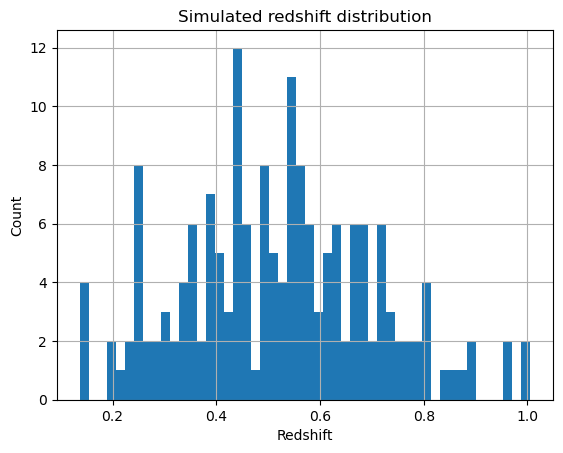

In [19]:
# redshift distribution of simulated SNe
fig, ax = plt.subplots()
results["source_redshift"].hist(bins=50, ax=ax)
ax.set(xlabel="Redshift", ylabel="Count", title="Simulated redshift distribution")
plt.show()

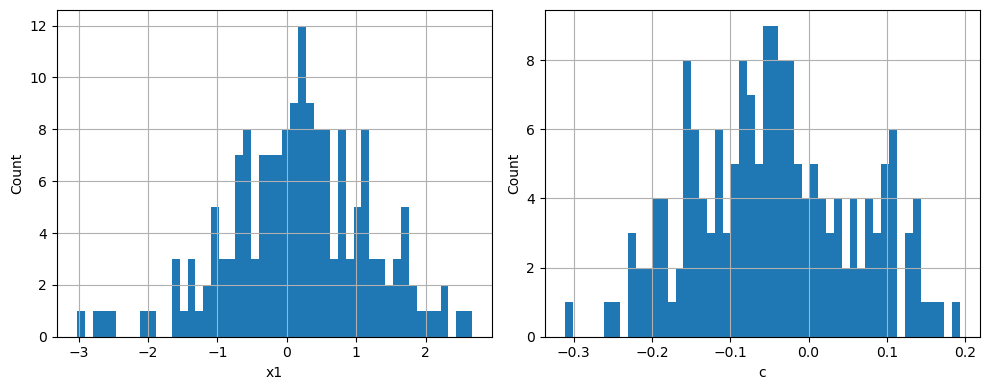

In [20]:
# x1 and c distributions
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
results["source_x1"].hist(bins=50, ax=axes[0])
axes[0].set(xlabel="x1", ylabel="Count")
results["source_c"].hist(bins=50, ax=axes[1])
axes[1].set(xlabel="c", ylabel="Count")
plt.tight_layout()
plt.show()

             mjd filter         flux     fluxerr  flux_perfect  survey_idx  \
0   60874.322459      g  2617.375765  345.063461   2993.762876           0   
1   60874.322895      g  2863.474912  333.779971   2993.924059           0   
..           ...    ...          ...         ...           ...         ...   
89  60914.287772      i  2174.935257  218.773773   2292.327190           0   
90  60914.288209      i  2600.168226  202.578843   2292.285386           0   

    obs_idx  is_saturated        zp        snr  detection_flag  
0       172         False  0.563309   7.585201            True  
1       173         False  0.571411   8.578930            True  
..      ...           ...       ...        ...             ...  
89      563         False  0.595919   9.941481            True  
90      564         False  0.593687  12.835340            True  

[91 rows x 11 columns]


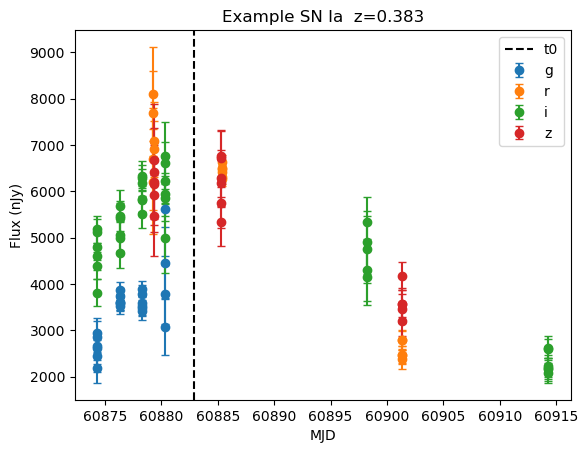

In [21]:
# example light curve for a single SN
sn = results.iloc[np.random.choice(len(results))]
lc = sn["lightcurve"]
print(lc)
for band in SIM_PARAMS["filters"]:
    mask = lc["filter"] == band
    mask &= (lc["mjd"] - sn["source_t0"])/(1. + sn["source_redshift"]) > -20  # only show points within 20 days before t0
    mask &= (lc["mjd"] - sn["source_t0"])/(1. + sn["source_redshift"]) < 100   # only show points within 20 days after t0
    if mask.any():
        plt.errorbar(lc["mjd"][mask], lc["flux"][mask], lc["fluxerr"][mask],
                     fmt="o", label=band, capsize=3)
plt.axvline(sn["source_t0"], ls="--", color="k", label="t0")
plt.legend()
plt.xlabel("MJD")
plt.ylabel("Flux (nJy)")
plt.title(f'Example SN Ia  z={sn["source_redshift"]:.3f}')
plt.show()

In [22]:
# append system path 

from utils.lcfit import fit_single_lc  

def fit_single_lc_w_cond(lc,
                         bounds={"x1": (-4,4),
                                 "c": (-0.4,0.4),},
                         phase_range=(-10,40),
                         modelcov=False):
    return fit_single_lc(lc,mpbounds=bounds,phase_range=phase_range,modelcov=modelcov)

In [23]:
res = fit_single_lc_w_cond(lightcurves_after_quality_cut.iloc[0])
res

success        1.0
ncall        171.0
             ...  
id             3.0
fit_error      NaN
Length: 54, dtype: float64

In [24]:
lc_to_fit = lightcurves_after_quality_cut.iloc[0:]

In [25]:
%%time
fit_results = Parallel(n_jobs=10)(delayed(fit_single_lc_w_cond)(row) for _index, row in lc_to_fit.iterrows())
result_df = pd.DataFrame(fit_results)

CPU times: user 369 ms, sys: 187 ms, total: 557 ms
Wall time: 12.8 s


In [26]:
saltparcuts = (result_df.x1 > -3) & (result_df.x1 < 3)
saltparcuts &= (result_df.c > -0.3) & (result_df.c < 0.3)
saltparcuts &= (result_df.success == True)

<Axes: >

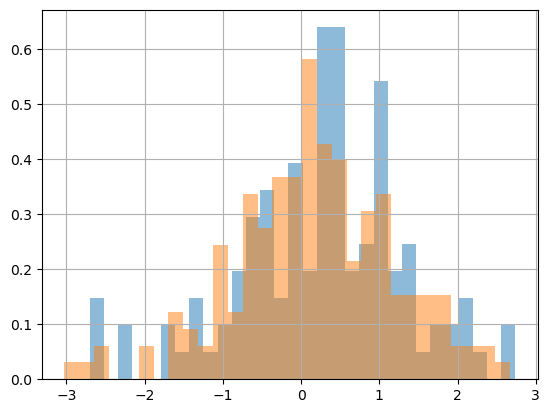

In [27]:
result_df[saltparcuts].x1.hist(bins=30,alpha=0.5,density=True)
lightcurves_after_quality_cut.source_x1.hist(bins=30,alpha=0.5,density=True)

<Axes: >

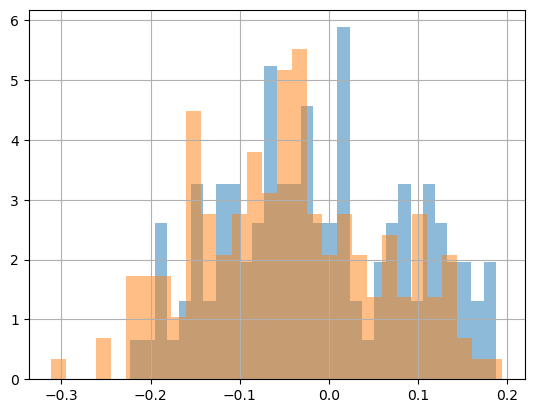

In [28]:
result_df[saltparcuts].c.hist(bins=30,alpha=0.5,density=True)
lightcurves_after_quality_cut.source_c.hist(bins=30,alpha=0.5,density=True)